In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [3]:
# 1. Load Cleaned Dataset
df = pd.read_csv(r"C:\Users\annus\Cleaned_Employee_HR.csv")

# Drop non_predictive identifier columns
if 'emp-id' in df.columns:
    df.drop(columns=['emp_id'], inplace=True)
if 'churn_label' in df.columns:
    df.drop(columns=['churn_label'], inplace=True)

In [4]:
# 2. Encode Categorical Variables
df = pd.get_dummies(df, columns=['department'], drop_first=True)

In [5]:
# 3. Separate Features (X) and Target (y)
X =df.drop(columns=['left'])
y = df['left']

In [6]:
# 4. Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [7]:
# 5. Model Training (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
# 6. Predictions & Evaluation
y_pred = rf_model.predict(X_test)
y_probs = rf_model.predict_proba(X_test)[:, 1]

print("=== MODEL PERFORMANCE EVALUATION ===")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}\n")
print("Classification Reprot:")
print(classification_report(y_test, y_pred))

=== MODEL PERFORMANCE EVALUATION ===
ROC-AUC Score: 1.0000

Classification Reprot:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2286
           1       1.00      0.99      0.99       714

    accuracy                           1.00      3000
   macro avg       1.00      0.99      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [11]:
# 7. Feature Importance Analysis
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("=== TOP ATTRITION DRIVERS ===")
print(feature_importances.head(10).to_string(index=False))

=== TOP ATTRITION DRIVERS ===
              Feature  Importance
               emp_id    0.417795
         satisfaction    0.205245
   number_of_projects    0.122968
   time_spent_company    0.085384
average_monthly_hours    0.082482
           evaluation    0.067478
           salary_inr    0.008696
        work_accident    0.005588
 department_technical    0.000983
            promotion    0.000756


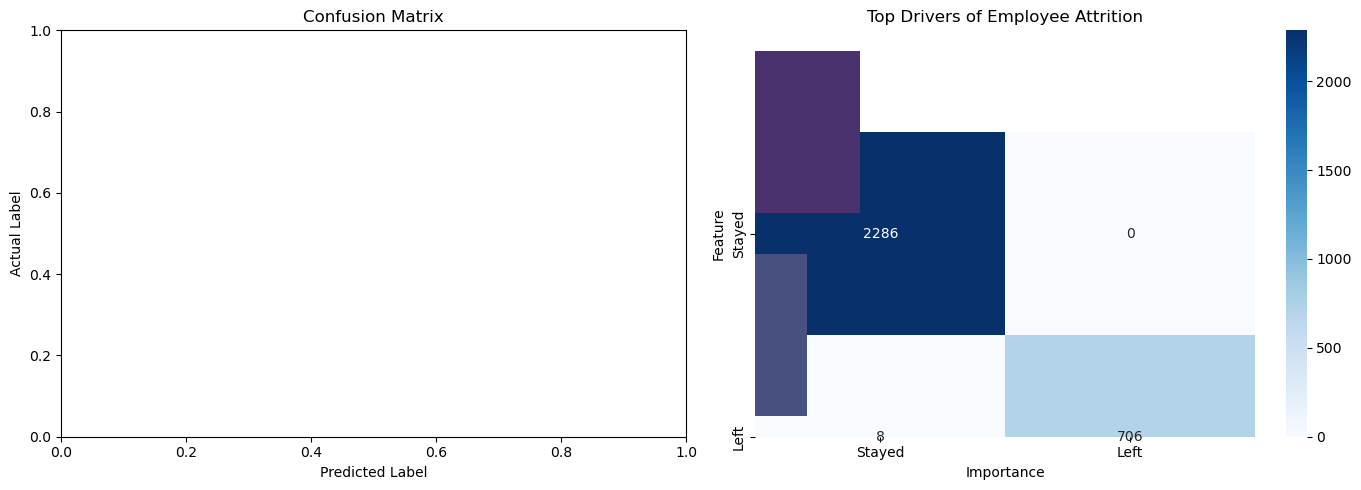

In [16]:
# -----------------------------------------------------------------------------------------------------------------------------
# VISUALIZATIONS: Confusion Matrix & Feature Importance
# -----------------------------------------------------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Confusion Matrix
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left']
)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')

# Plot B: Feature Importance Barplot
sns.barplot(
    data=feature_importances.head(8),
    x='Importance', 
    y='Feature', 
    hue='Feature', 
    palette='viridis', 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title('Top Drivers of Employee Attrition')

plt.tight_layout()
plt.show()